In [4]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Import Library
import pandas as pd

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Indian_Kids_Screen_Time.csv')

# Show First Rows
print(df.head())

# Dataset Info
print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor S

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                9668 non-null   int64   
 1   Gender                             9668 non-null   object  
 2   Avg_Daily_Screen_Time_hr           9668 non-null   float64 
 3   Primary_Device                     9668 non-null   object  
 4   Exceeded_Recommended_Limit         9668 non-null   bool    
 5   Educational_to_Recreational_Ratio  9668 non-null   float64 
 6   Health_Impacts                     9668 non-null   object  
 7   Urban_or_Rural                     9668 non-null   object  
 8   Age_Band                           7911 non-null   category
 9   Day                                9668 non-null   object  
 10  Day_Type                           9668 non-null   object  
dtypes: bool(1), category(1), float64(2), int64(1), o

In [11]:
print("Rows & Columns:", df.shape)

Rows & Columns: (9668, 11)


In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Band,1757
Day,0


In [13]:
df.describe(include='all')

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Day,Day_Type
count,9668.000000,9668,9668.000000,9668,9668,9668.000000,9668,9668,7911,9668,9668
unique,NaN,2,NaN,4,2,NaN,15,2,3,7,2
top,NaN,Male,NaN,Smartphone,True,NaN,Poor Sleep,Urban,Teen,Tuesday,Weekday
freq,NaN,4928,NaN,4540,8292,NaN,3399,6810,3543,1446,6905
mean,12.992760,NaN,4.367780,NaN,NaN,0.427028,NaN,NaN,NaN,NaN,NaN
std,3.158931,NaN,1.703002,NaN,NaN,0.073185,NaN,NaN,NaN,NaN,NaN
min,8.000000,NaN,0.000000,NaN,NaN,0.300000,NaN,NaN,NaN,NaN,NaN
25%,10.000000,NaN,3.427500,NaN,NaN,0.370000,NaN,NaN,NaN,NaN,NaN
50%,13.000000,NaN,4.440000,NaN,NaN,0.430000,NaN,NaN,NaN,NaN,NaN
75%,16.000000,NaN,5.380000,NaN,NaN,0.480000,NaN,NaN,NaN,NaN,NaN


In [14]:
df.dtypes

,0
Age,int64
Gender,object
Avg_Daily_Screen_Time_hr,float64
Primary_Device,object
Exceeded_Recommended_Limit,bool
Educational_to_Recreational_Ratio,float64
Health_Impacts,object
Urban_or_Rural,object
Age_Band,category
Day,object


In [15]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipykernel_156/1174305217.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Band,1757
Day,0


In [16]:
bins = [5, 10, 13, 16, 18]
labels = ['6-10', '11-13', '14-16', '17-18']

df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age', 'Age_Band']].head()

,Age,Age_Band
0,14,14-16
1,11,11-13
2,18,17-18
3,15,14-16
4,12,11-13


In [27]:
# Auto detect date column
date_col = None
for col in df.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col:
    df[date_col] = pd.to_datetime(df[date_col])
    df['Day_Name'] = df[date_col].dt.day_name()
    df['Week_Type'] = np.where(df['Day_Name'].isin(['Saturday','Sunday']),
                               'Weekend','Weekday')

week_table = df['Week_Type'].value_counts().reset_index()
week_table.columns = ["Week Type", "Count"]

week_table

,Week Type,Count
0,Weekday,6905
1,Weekend,2763


In [18]:
# The 'Date' column was not found. Assuming the existing 'Day' column (which contains day names)
# is intended to be used for creating Day_Name and Week_Type.

# Use the existing 'Day' column as 'Day_Name'
df['Day_Name'] = df['Day']

df['Week_Type'] = df['Day_Name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

df[['Day', 'Day_Name', 'Week_Type']].head()

,Day,Day_Name,Week_Type
0,Friday,Friday,Weekday
1,Thursday,Thursday,Weekday
2,Saturday,Saturday,Weekend
3,Sunday,Sunday,Weekend
4,Friday,Friday,Weekday


In [35]:
import numpy as np
base_device_keywords = ['mobile', 'tv', 'laptop', 'tablet']
current_base_device_cols = []

for col in df.columns:
    col_lower = col.lower()
    is_base_col = False
    for keyword in base_device_keywords:
        if keyword in col_lower and '_share' not in col_lower:
            current_base_device_cols.append(col)
            is_base_col = True
            break

device_cols = list(set(current_base_device_cols))

if len(device_cols) > 0:

    for col in device_cols:
        if col not in df.columns:
            df[col] = 0.0

    df['Total_Device_Hours'] = df[device_cols].sum(axis=1)
    df['Total_Device_Hours_Safe'] = df['Total_Device_Hours'].replace(0, np.nan)

    for col in device_cols:
        df[col + '_Share'] = df[col] / df['Total_Device_Hours_Safe']

    for col_share in [col + '_Share' for col in device_cols]:
        df[col_share] = df[col_share].fillna(0)
    df = df.drop(columns=['Total_Device_Hours_Safe'])

device_share_table = df[[col + '_Share' for col in device_cols]].head()

device_share_table

,TV_Hours_Share,Laptop_Hours_Share,Mobile_Hours_Share
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


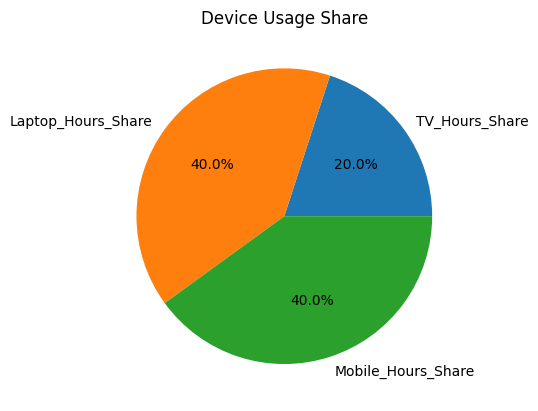

In [33]:
import matplotlib.pyplot as plt

# Calculate the mean share for each device type to represent overall usage
device_share = device_share_table.mean().squeeze()

device_share.plot(kind='pie', autopct='%1.1f%%')
plt.title("Device Usage Share")
plt.ylabel("")
plt.show()

In [29]:
activity_cols = [col for col in df.columns if 'gaming' in col.lower()
                 or 'study' in col.lower()
                 or 'social' in col.lower()
                 or 'video' in col.lower()]

if len(activity_cols) > 0:
    df['Total_Activity_Hours'] = df[activity_cols].sum(axis=1)

    for col in activity_cols:
        df[col + '_Share'] = df[col] / df['Total_Activity_Hours']

activity_share_table = df[[col + '_Share' for col in activity_cols]].head()

activity_share_table

,Gaming_Hours_Share,Study_Hours_Share,SocialMedia_Hours_Share,Gaming_Hours_Share_Share,Study_Hours_Share_Share,SocialMedia_Hours_Share_Share
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
df.to_csv('Cleaned_Indian_Kids_Screen_Time.csv', index=False)